# Wellengeschwindigkeiten und Wellenlängen

Vergleich der Phasengeschwindigkeiten und Wellenlängen verschiedener
Wellentypen in einem Stahlbalken: Longitudinalwelle, Quasi-Longitudinalwelle,
Transversal-/Torsionswelle, Biegewelle und Schallwelle in Luft.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hoeverc/laermarmesysteme_medien/blob/main/Python/VL4/Wellengeschwindigkeiten.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Materialparameter und Geometrie

Schallgeschwindigkeit in Luft, Materialeigenschaften (Stahl) und
Balkengeometrie. Weitere Materialien (Aluminium, Plexiglas)
können durch Ändern der Kommentare aktiviert werden.

In [2]:
# Schallgeschwindigkeit Luft
c_0=340

# Materialeigenschaften Stahl
E=210e9       # Elastizitätsmodul
nu=0.3        # Poissonzahl
rho=7900      # Dichte

# # Aluminium
# E=70e9
# nu=0.32
# rho=2700

# # Plexiglas
# E=5.6e9
# nu=0.3
# rho=1150

# Balkengeometrie
b=0.05        # Breite
h=1e-2        # Dicke

# Frequenzvektor
f=np.arange(1, 5001)

## Abgeleitete Größen und Wellengeschwindigkeiten

Berechnung von Schubmodul $G$, Flächenträgheitsmoment $I$,
Biegesteifigkeit $B$ und Masse pro Länge $m'$.

Phasengeschwindigkeiten:
- Longitudinalwelle: $c_L = \sqrt{1{,}35\,E/\rho}$
- Quasi-Longitudinalwelle (Balken): $c_{Lb} = \sqrt{E/\rho}$
- Transversal-/Torsionswelle: $c_T = \sqrt{G/\rho}$
- Biegewelle (dispersiv): $c_B = (B/m')^{1/4}\,\sqrt{\omega}$

In [3]:
# Abgeleitete Größen
G=E/(2*(1+nu))          # Schubmodul
I_beam=b*h**3/12        # Flächenträgheitsmoment (Rechteck)
B=E*I_beam              # Biegesteifigkeit
mprime=rho*b*h          # Masse pro Länge

omega=2*np.pi*f

# Phasengeschwindigkeiten
c_L=np.sqrt(1.35*E/rho)                  # Longitudinalwelle
c_Lb=np.sqrt(E/rho)                      # Quasi-Longitudinalwelle (Balken)
c_T=np.sqrt(G/rho)                       # Transversal-/Torsionswelle
c_B=(B/mprime)**0.25*np.sqrt(omega)       # Biegewelle

# Wellenlängen
lambda_0=c_0/f
lambda_L=c_L/f
lambda_Lb=c_Lb/f
lambda_T=c_T/f
lambda_B=c_B/f

print(f"c_L  = {c_L:.0f} m/s")
print(f"c_Lb = {c_Lb:.0f} m/s")
print(f"c_T  = {c_T:.0f} m/s")
print(f"c_0  = {c_0} m/s")

c_L  = 5990 m/s
c_Lb = 5156 m/s
c_T  = 3197 m/s
c_0  = 340 m/s


## Plot: Phasengeschwindigkeit und Wellenlänge

Schrittweiser Aufbau der Diagramme – jede Zelle fügt einen
weiteren Wellentyp hinzu (entspricht den `pause`-Schritten
im MATLAB-Original).

In [4]:
fontsize=16
titlefontsize=20
linewidth=2

def make_figure(wave_speeds, wave_lambdas, labels):
  """Erzeugt ein zweispaltiges Diagramm (Phasengeschwindigkeit | Wellenlänge)."""
  fig, (ax1, ax2)=plt.subplots(1, 2, figsize=(14, 6))
  fig.set_facecolor('w')

  for cc, lam, lab in zip(wave_speeds, wave_lambdas, labels):
    if np.isscalar(cc):
      ax1.plot([f[0], f[-1]], [cc, cc], linewidth=linewidth, label=lab)
    else:
      ax1.plot(f, cc, linewidth=linewidth, label=lab)
    ax2.semilogy(f, lam, linewidth=linewidth, label=lab)

  ax1.set_xlabel("f in Hz", fontsize=fontsize)
  ax1.set_ylabel("Geschwindigkeit in m/s", fontsize=fontsize)
  ax1.set_title("Phasengeschwindigkeit", fontsize=titlefontsize)
  ax1.set_ylim(0, c_L+100)
  ax1.legend(fontsize=fontsize-2, loc="upper left")
  ax1.tick_params(labelsize=fontsize-2)

  ax2.set_xlabel("f in Hz", fontsize=fontsize)
  ax2.set_ylabel("Wellenlänge in m", fontsize=fontsize)
  ax2.set_title("Wellenlänge", fontsize=titlefontsize)
  ax2.legend(fontsize=fontsize-2, loc="upper right")
  ax2.tick_params(labelsize=fontsize-2)

  fig.tight_layout()
  plt.show()

### 1 – Longitudinalwelle

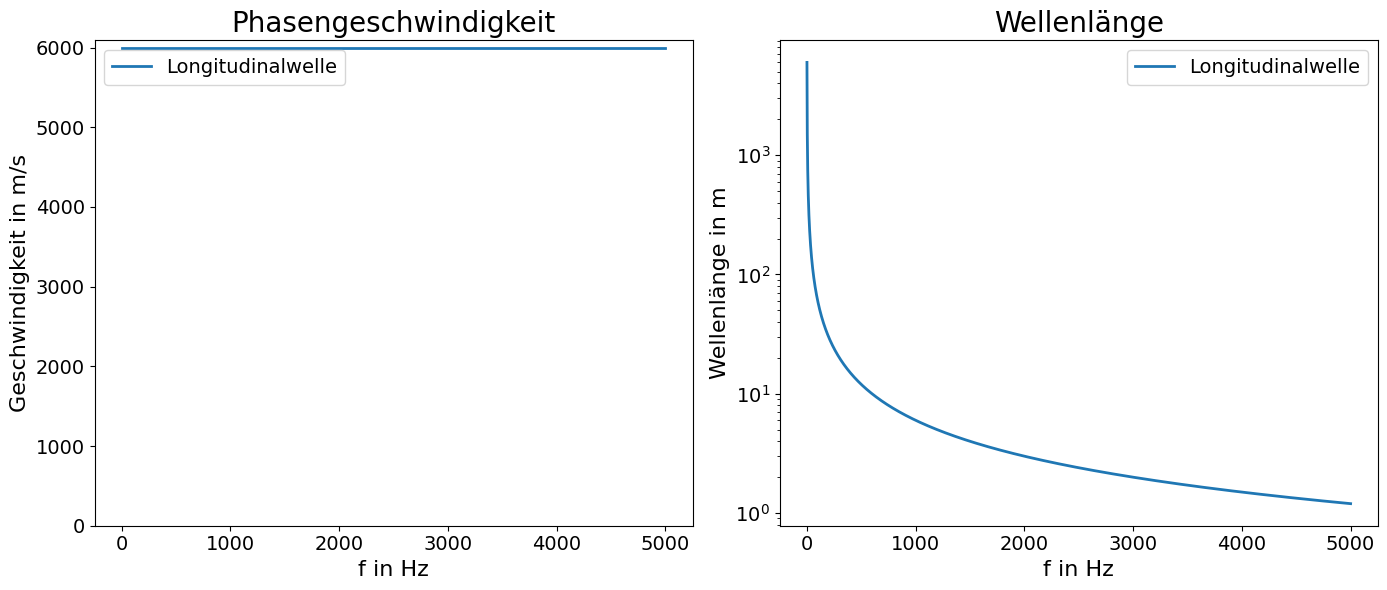

In [5]:
make_figure(
  [c_L],
  [lambda_L],
  ["Longitudinalwelle"])

### 2 – + Quasi-Longitudinalwelle

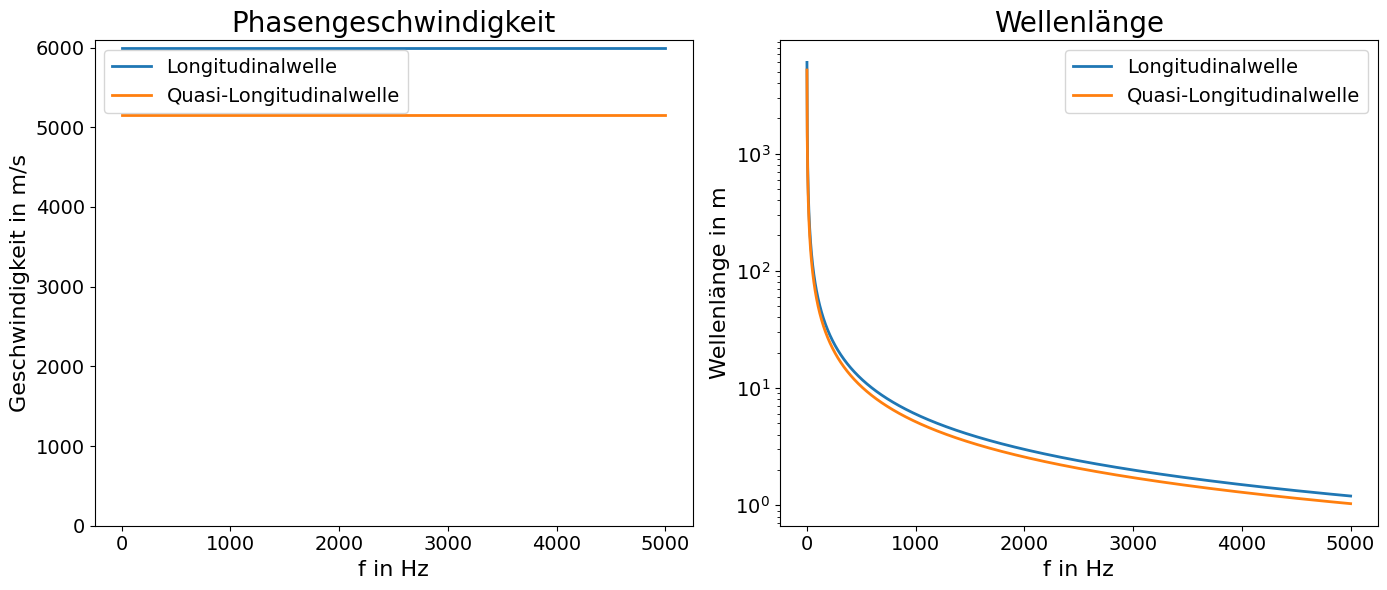

In [6]:
make_figure(
  [c_L, c_Lb],
  [lambda_L, lambda_Lb],
  ["Longitudinalwelle", "Quasi-Longitudinalwelle"])

### 3 – + Transversal-/Torsionswelle

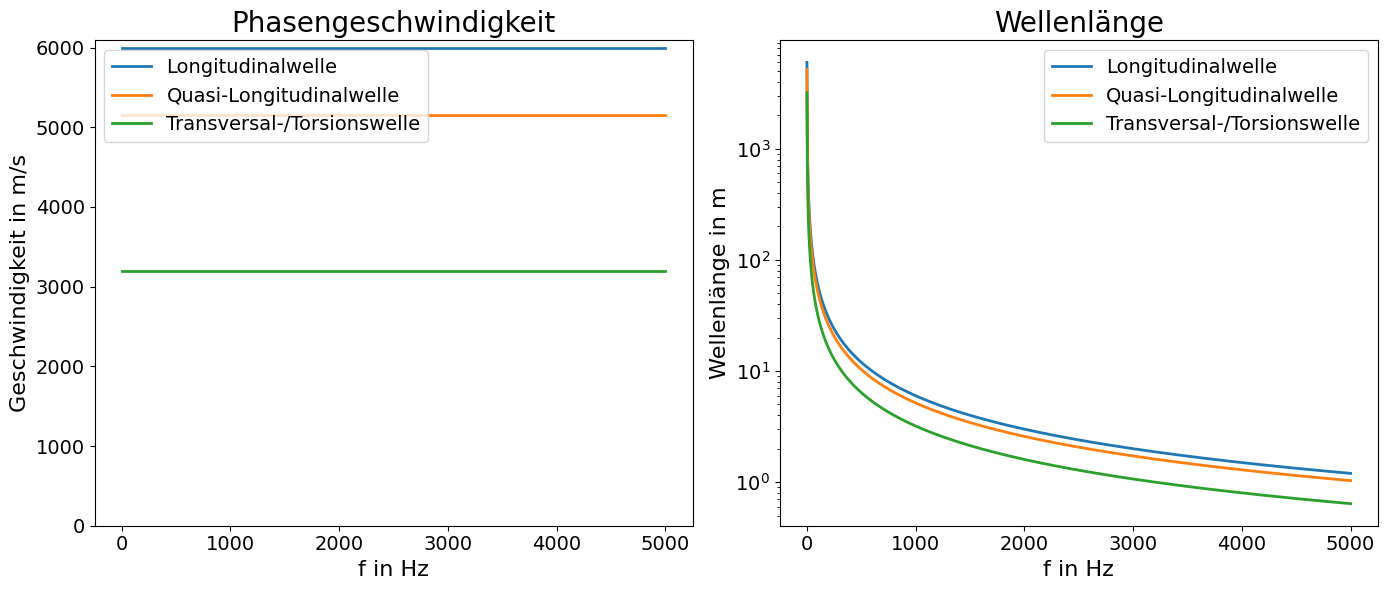

In [7]:
make_figure(
  [c_L, c_Lb, c_T],
  [lambda_L, lambda_Lb, lambda_T],
  ["Longitudinalwelle", "Quasi-Longitudinalwelle",
   "Transversal-/Torsionswelle"])

### 4 – + Biegewelle (dispersiv)

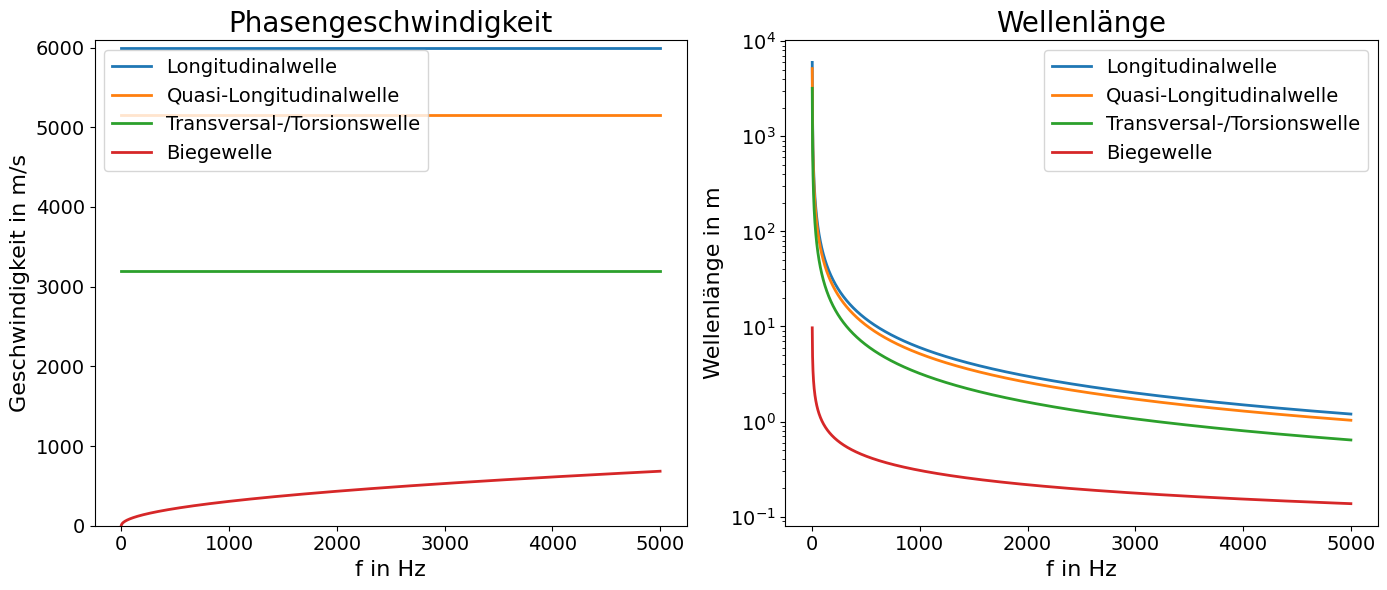

In [8]:
make_figure(
  [c_L, c_Lb, c_T, c_B],
  [lambda_L, lambda_Lb, lambda_T, lambda_B],
  ["Longitudinalwelle", "Quasi-Longitudinalwelle",
   "Transversal-/Torsionswelle", "Biegewelle"])

### 5 – + Luft

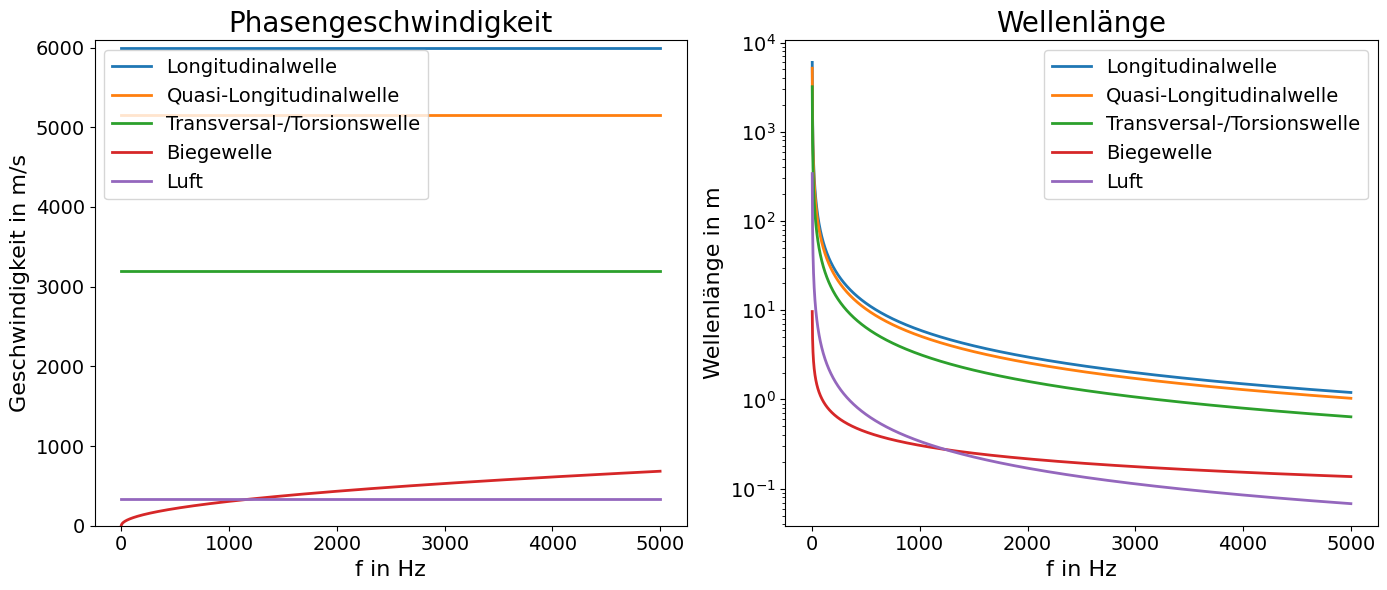

In [9]:
make_figure(
  [c_L, c_Lb, c_T, c_B, c_0],
  [lambda_L, lambda_Lb, lambda_T, lambda_B, lambda_0],
  ["Longitudinalwelle", "Quasi-Longitudinalwelle",
   "Transversal-/Torsionswelle", "Biegewelle", "Luft"])